In [85]:

!pip install langgraph langchain langchain-google-genai

In [86]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,List
from langchain_google_genai import ChatGoogleGenerativeAI
import os,random


In [87]:
os.environ['GOOGLE_API_KEY']="xyz"

In [88]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",

)

In [89]:
class LoanState(TypedDict, total=False):

    # Inputs
    applicant_name: str
    employment_type: str
    requested_loan_amount: float
    monthly_income: float
    monthly_expenses: float
    credit_score: int
    submitted_documents: List[str]

    # Stage 1
    applicant_profile: str
    income_stability: str
    missing_documents: List[str]
    spending_pattern: str
    financial_behavior: str

    # Stage 2
    kyc_status: str
    employment_verification: str
    bureau_validation: str
    fraud_risk_score: float
    debt_to_income_ratio: float

    # Stage 3
    route: str
    investigation_notes: str
    clarification_message: str
    rejection_reason: str
    review_notes: str
    fast_track_status: str

    # Stage 4
    final_decision: str
    approval_rationale: str
    risk_summary: str
    recommended_loan_amount: float
    interest_rate: float
    applicant_notification: str

In [90]:
def applicant_profile_agent(state: LoanState):

    prompt = f"""
    You are an Applicant Profile Analysis Agent.

    Analyze the following loan applicant profile.

    Applicant Name:
    {state['applicant_name']}

    Employment Type:
    {state['employment_type']}

    Monthly Income:
    {state['monthly_income']}

    Credit Score:
    {state['credit_score']}

    Generate:
    - Applicant profile summary
    - Financial strength
    - Risk observation
    """

    response = llm.invoke(prompt)

    return {
        "applicant_profile": response.content.strip().lower()
    }

In [91]:
def income_stability_agent(state: LoanState):

    prompt = f"""
    You are an Income Stability Analysis Agent.

    Analyze the applicant income stability.

    Employment Type:
    {state['employment_type']}

    Monthly Income:
    {state['monthly_income']}

    Categorize income stability as:
    - High
    - Medium
    - Low

    Return only category.
    """

    response = llm.invoke(prompt)

    return {
        "income_stability": response.content.strip()
    }


In [92]:
def missing_document_agent(state: LoanState):

    required_docs = {
        "ID Proof",
        "Salary Slip",
        "Bank Statement"
    }

    submitted = set(state["submitted_documents"])

    missing = list(required_docs - submitted)

    return {
        "missing_documents": missing
    }

In [93]:
def spending_pattern_agent(state: LoanState):

    prompt = f"""
    You are a Spending Pattern Analysis Agent.

    Analyze applicant spending behavior.

    Monthly Income:
    {state['monthly_income']}

    Monthly Expenses:
    {state['monthly_expenses']}

    Categorize as:
    - Healthy Spending
    - Moderate Spending
    - High Spending

    Return only category.
    """

    response = llm.invoke(prompt)

    return {
        "spending_pattern": response.content.strip()
    }

In [94]:
def financial_behavior_agent(state: LoanState):

    prompt = f"""
    You are a Financial Behavior Analysis Agent.

    Analyze the financial behavior.

    Credit Score:
    {state['credit_score']}

    Categorize as:
    - Excellent
    - Average
    - Risky

    Return only category.
    """

    response = llm.invoke(prompt)

    return {
        "financial_behavior": response.content.strip()
    }

In [95]:
def kyc_verification_agent(state: LoanState):

    if "ID Proof" in state["submitted_documents"]:
        status = "Verified"
    else:
        status = "Failed"

    return {
        "kyc_status": status
    }


In [96]:
def employment_verification_agent(state: LoanState):

    prompt = f"""
    You are an Employment Verification Agent.

    Verify applicant employment eligibility.

    Employment Type:
    {state['employment_type']}

    Return:
    - Verified
    - Pending
    """
    response = llm.invoke(prompt)

    return {
        "employment_verification": response.content.strip()
    }



In [97]:
def credit_bureau_agent(state: LoanState):

    prompt = f"""
    You are a Credit Bureau Validation Agent.

    Analyze credit score.

    Credit Score:
    {state['credit_score']}

    Categorize as:
    - Good
    - Moderate
    - Poor

    Return only category.
    """

    response = llm.invoke(prompt)

    return {
        "bureau_validation": response.content.strip()
    }



In [98]:
def fraud_detection_agent(state: LoanState):

    fraud_score = round(random.uniform(0, 1), 2)

    return {
        "fraud_risk_score": fraud_score
    }


In [99]:
def debt_to_income_agent(state: LoanState):

    ratio = round(
        state["monthly_expenses"] /
        state["monthly_income"],
        2
    )

    return {
        "debt_to_income_ratio": ratio
    }

In [100]:
def routing_agent(state: LoanState):

    fraud = state.get('fraud_risk_score', 0.0)
    missing = state.get('missing_documents', [])
    dti = state.get('debt_to_income_ratio', 0.0) # Use .get() with a default value
    credit = state.get('credit_score', 0)

    if fraud > 0.8:

        route = "fraud"

    elif len(missing) > 0:

        route = "clarification"

    elif dti > 0.75:

        route = "rejection"

    elif credit >= 780 and fraud < 0.3:

        route = "fast_track"

    else:

        route = "manual_review"

    return {
        "route": route
    }

In [101]:
def fraud_investigation_agent(state: LoanState):

    prompt = f"""
    You are a Fraud Investigation Agent.

    Fraud Risk Score:
    {state['fraud_risk_score']}

    Generate short investigation notes.
    """

    response = llm.invoke(prompt)

    return {
        "investigation_notes": response.content
    }

In [102]:
def clarification_agent(state: LoanState):

    docs = ", ".join(state["missing_documents"])

    prompt = f"""
    You are a Clarification Agent.

    Missing Documents:
    {docs}

    Generate professional clarification message.
    """

    response = llm.invoke(prompt)

    return {
        "clarification_message": response.content
    }


In [103]:
def rejection_recommendation_agent(state: LoanState):

    prompt = f"""
    You are a Rejection Recommendation Agent.

    Debt-To-Income Ratio:
    {state['debt_to_income_ratio']}

    Generate concise rejection reason.
    """

    response = llm.invoke(prompt)

    return {
        "rejection_reason": response.content
    }

In [104]:
def fast_track_approval_agent(state: LoanState):

    prompt = f"""
    You are a Fast Track Approval Agent.

    Credit Score:
    {state['credit_score']}

    Fraud Risk:
    {state['fraud_risk_score']}

    Generate fast-track approval summary.
    """

    response = llm.invoke(prompt)
    return {
        "fast_track_status": response.content
    }

In [105]:
def manual_review_agent(state: LoanState):

    prompt = f"""
    You are a Manual Review Agent.

    Analyze medium-risk loan application.

    Generate review notes for underwriter.
    """

    response = llm.invoke(prompt)

    return {
        "review_notes": response.content
    }


In [106]:
def decision_agent(state: LoanState):

    prompt = f"""
    You are a Loan Decision Agent.

    Route:
    {state['route']}

    Credit Score:
    {state['credit_score']}

    Fraud Risk:
    {state['fraud_risk_score']}

    Debt-To-Income Ratio:
    {state['debt_to_income_ratio']}

    Generate:
    - Final Decision
    - Approval/Rejection rationale
    """

    response = llm.invoke(prompt)

    return {
        "final_decision": response.content,
        "approval_rationale": response.content
    }

In [107]:
def risk_summary_agent(state: LoanState):

    prompt = f"""
    You are a Risk Summary Agent.

    Generate concise financial risk summary.

    Credit Score:
    {state['credit_score']}

    Fraud Risk:
    {state['fraud_risk_score']}

    Debt-To-Income Ratio:
    {state['debt_to_income_ratio']}

    Financial Behavior:
    {state['financial_behavior']}
    """

    response = llm.invoke(prompt)

    return {
        "risk_summary": response.content
    }





In [108]:
def loan_recommendation_agent(state: LoanState):

    income = state["monthly_income"]

    recommended_amount = income * 20

    score = state["credit_score"]

    if score >= 780:
        interest = 8.5

    elif score >= 700:
        interest = 10.5

    else:
        interest = 14.0

    return {
        "recommended_loan_amount": recommended_amount,
        "interest_rate": interest
    }

In [109]:
def notification_agent(state: LoanState):

    prompt = f"""
    You are a Loan Notification Agent.

    Applicant Name:
    {state['applicant_name']}

    Final Decision:
    {state['final_decision']}

    Recommended Loan Amount:
    {state['recommended_loan_amount']}

    Interest Rate:
    {state['interest_rate']}

    Generate professional applicant notification.
    """

    response = llm.invoke(prompt)

    return {
        "applicant_notification": response.content
    }

In [110]:
def route_condition(state: LoanState):

    return state["route"]

graph = StateGraph(LoanState)

# Stage 1
graph.add_node(
    "applicant_profile_agent",
    applicant_profile_agent
)

graph.add_node(
    "income_stability_agent",
    income_stability_agent
)

graph.add_node(
    "missing_document_agent",
    missing_document_agent
)

graph.add_node(
    "spending_pattern_agent",
    spending_pattern_agent
)

graph.add_node(
    "financial_behavior_agent",
    financial_behavior_agent
)

# Stage 2
graph.add_node(
    "kyc_verification_agent",
    kyc_verification_agent
)

graph.add_node(
    "employment_verification_agent",
    employment_verification_agent
)

graph.add_node(
    "credit_bureau_agent",
    credit_bureau_agent
)

graph.add_node(
    "fraud_detection_agent",
    fraud_detection_agent
)

graph.add_node(
    "debt_to_income_agent",
    debt_to_income_agent
)

# Stage 3
graph.add_node(
    "routing_agent",
    routing_agent
)

graph.add_node(
    "fraud_investigation_agent",
    fraud_investigation_agent
)

graph.add_node(
    "clarification_agent",
    clarification_agent
)

graph.add_node(
    "rejection_recommendation_agent",
    rejection_recommendation_agent
)

graph.add_node(
    "fast_track_approval_agent",
    fast_track_approval_agent
)

graph.add_node(
    "manual_review_agent",
    manual_review_agent
)

# Stage 4
graph.add_node(
    "decision_agent",
    decision_agent
)

graph.add_node(
    "risk_summary_agent",
    risk_summary_agent
)

graph.add_node(
    "loan_recommendation_agent",
    loan_recommendation_agent
)

graph.add_node(
    "notification_agent",
    notification_agent
)

In [111]:
graph.set_entry_point(
    "applicant_profile_agent"
)

# Stage 1 Parallel
graph.add_edge(
    "applicant_profile_agent",
    "income_stability_agent"
)

graph.add_edge(
    "applicant_profile_agent",
    "missing_document_agent"
)

graph.add_edge(
    "applicant_profile_agent",
    "spending_pattern_agent"
)

graph.add_edge(
    "applicant_profile_agent",
    "financial_behavior_agent"
)

# Stage 2
graph.add_edge(
    "income_stability_agent",
    "kyc_verification_agent"
)

graph.add_edge(
    "missing_document_agent",
    "employment_verification_agent"
)

graph.add_edge(
    "spending_pattern_agent",
    "credit_bureau_agent"
)

graph.add_edge(
    "financial_behavior_agent",
    "fraud_detection_agent"
)

graph.add_edge(
    "fraud_detection_agent",
    "debt_to_income_agent"
)

# Routing
graph.add_edge(
    "kyc_verification_agent",
    "routing_agent"
)

graph.add_edge(
    "employment_verification_agent",
    "routing_agent"
)

graph.add_edge(
    "credit_bureau_agent",
    "routing_agent"
)

graph.add_edge(
    "debt_to_income_agent",
    "routing_agent"
)

# Conditional Routing
graph.add_conditional_edges(
    "routing_agent",
    route_condition,
    {
        "fraud":
            "fraud_investigation_agent",

        "clarification":
            "clarification_agent",

        "rejection":
            "rejection_recommendation_agent",

        "fast_track":
            "fast_track_approval_agent",

        "manual_review":
            "manual_review_agent"
    }
)

# Final Decision
graph.add_edge(
    "fraud_investigation_agent",
    "decision_agent"
)

graph.add_edge(
    "clarification_agent",
    "decision_agent"
)

graph.add_edge(
    "rejection_recommendation_agent",
    "decision_agent"
)

graph.add_edge(
    "fast_track_approval_agent",
    "decision_agent"
)

graph.add_edge(
    "manual_review_agent",
    "decision_agent"
)

# Final Parallel Tasks
graph.add_edge(
    "decision_agent",
    "risk_summary_agent"
)

graph.add_edge(
    "decision_agent",
    "loan_recommendation_agent"
)

graph.add_edge(
    "risk_summary_agent",
    "notification_agent"
)

graph.add_edge(
    "loan_recommendation_agent",
    "notification_agent"
)

graph.add_edge(
    "notification_agent",
    END
)

In [112]:
workflow=graph.compile()

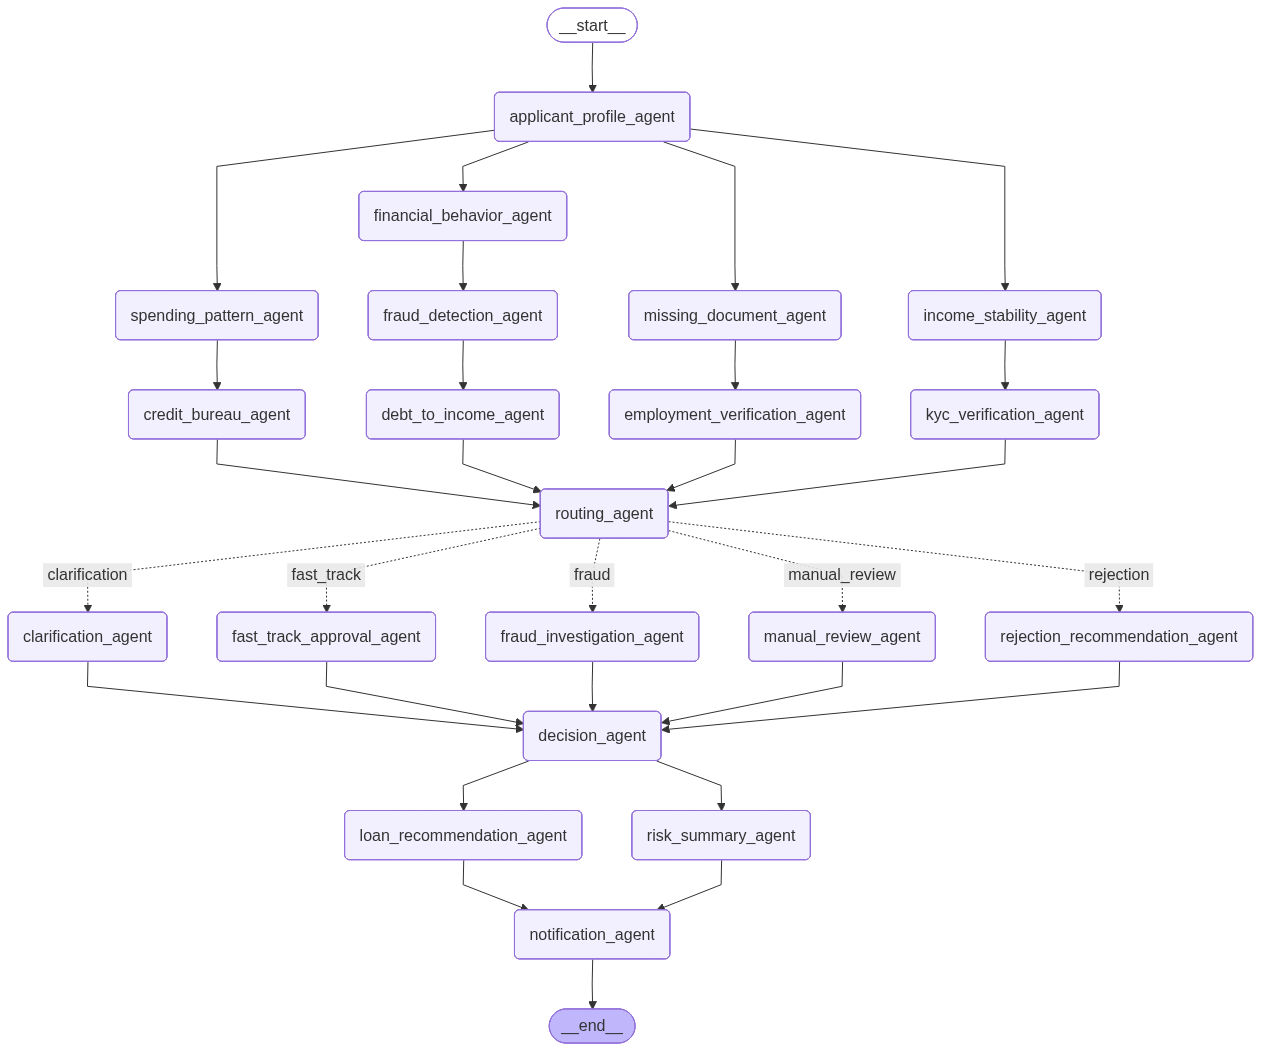

In [113]:
workflow